# Laboratorio #1

## Entender el dataset y limpiar

| tourney_date | surface | best_of | winner_name | winner_rank | loser_rank | w_ace | l_ace | minutes |
| ------------ | ------- | ------- | ----------- | ----------- | ---------- | ----- | ----- | ------- |
| 20220128     | Hard    | 3       | Nadal       | 5           | 122        | 8     | 3     | 95      |

El *28/01/2022* Nadal (ranking 5) vencio a alguien de *ranking 122* en *cancha dura* en un partido de hasta *3 sets*, con *8 aces* y el partido duro *95 minutos*

Nuestra mision es que el modelo aprenda a predecir *minutes* (duracion) a partir de todos los datos.

In [71]:
# Importar librerias

import pandas as pd
import numpy as np

In [72]:
# Cargar el archivo
df = pd.read_csv('../Datasets/1_ATP_matches_D/atp_matches_till_2022.csv')


In [73]:
# Explorar

print("Filas y Columnas: ", df.shape)
df.head(3)

Filas y Columnas:  (188161, 49)


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,1968-2029,Dublin,Grass,32,A,19680708,270,112411,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1968-2029,Dublin,Grass,32,A,19680708,271,126914,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1968-2029,Dublin,Grass,32,A,19680708,272,209523,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
df.describe()
# muestra: media, minimo, maximo, etc. De cada columna numerica

,draw_size,tourney_date,match_num,winner_id,winner_seed,winner_ht,winner_age,loser_id,loser_seed,loser_ht,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
count,188161.000000,1.881610e+05,188161.000000,188161.000000,69694.000000,171924.000000,186826.000000,188161.000000,35337.000000,159463.000000,...,92219.000000,92219.000000,92219.000000,92220.000000,92219.000000,92219.000000,153197.000000,105973.000000,144834.000000,104354.000000
mean,52.926292,1.993350e+07,76.618598,103820.251673,6.280225,184.449187,25.658362,104967.986995,7.667402,184.226592,...,48.011549,31.894892,14.985263,12.197387,4.812002,8.742884,75.255716,1366.471611,112.884150,859.219896
std,36.446303,1.544445e+05,110.714957,11470.048991,5.509548,6.667033,4.045128,14866.251405,5.995551,6.655036,...,19.390121,14.449465,7.220377,4.129834,3.275387,4.131839,121.053512,1726.089469,162.191701,987.192154
min,2.000000,1.968011e+07,1.000000,100001.000000,1.000000,160.000000,14.300000,100001.000000,1.000000,160.000000,...,0.000000,0.000000,0.000000,0.000000,-6.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,32.000000,1.980041e+07,10.000000,100402.000000,2.000000,180.000000,22.700000,100502.000000,4.000000,180.000000,...,34.000000,22.000000,10.000000,9.000000,2.000000,6.000000,17.000000,489.000000,37.000000,361.000000
50%,32.000000,1.993030e+07,25.000000,101686.000000,5.000000,185.000000,25.200000,101843.000000,6.000000,185.000000,...,45.000000,29.000000,14.000000,11.000000,4.000000,8.000000,44.000000,846.000000,70.000000,630.000000
75%,64.000000,2.006072e+07,80.000000,103898.000000,8.000000,188.000000,28.200000,104252.000000,10.000000,188.000000,...,58.000000,40.000000,19.000000,15.000000,7.000000,11.000000,86.000000,1532.000000,118.000000,1013.000000
max,128.000000,2.022113e+07,1701.000000,211468.000000,35.000000,211.000000,58.700000,211805.000000,35.000000,211.000000,...,328.000000,284.000000,101.000000,91.000000,28.000000,38.000000,2101.000000,16950.000000,2159.000000,16950.000000


In [75]:
df.isnull().sum()

# Ver cuantos datos faltantes hay por columna

tourney_id                 0
tourney_name               0
surface                 2317
draw_size                  0
tourney_level              0
tourney_date               0
match_num                  0
winner_id                  0
winner_seed           118467
winner_entry          171891
winner_name                0
winner_hand               17
winner_ht              16237
winner_ioc                10
winner_age              1335
loser_id                   0
loser_seed            152824
loser_entry           160432
loser_name                 0
loser_hand                64
loser_ht               28698
loser_ioc                 69
loser_age               4825
score                      8
best_of                    0
round                      0
minutes                98650
w_ace                  95941
w_df                   95942
w_svpt                 95942
w_1stIn                95942
w_1stWon               95942
w_2ndWon               95942
w_SvGms                95941
w_bpSaved     

In [76]:
# Definir columnas

# variables numericas (se usan directamente)

numericas = [
    "best_of",
    "winner_rank",
    "loser_rank_points",
    "winner_age",
    "loser_age",
    "w_ace",
    "l_ace",
    "w_df",
    "l_df",
    "w_svpt",
    "l_svpt",
    "w_1stIn",
    "l_1stIn",
    "w_1stWon",
    "l_1stWon",
    "w_2ndWon",
    "l_2ndWon",
    "w_bpSaved",
    "l_bpSaved",
    "w_bpFaced",
    "l_bpFaced"
]

# Variables de texto (se convertiran a numeros)
categorias = ["surface", "tourney_level", "round"]

# Variable Objetivo
target = "minutes"

In [77]:
# Nos quedamos solo con estas columnas para el modelo

df_modelo = df[numericas + categorias + [target]].copy()

print("Columnas selecccionadas: ", df_modelo.shape[1])
print("Partidos iniciales: ", df_modelo.shape[0])

Columnas selecccionadas:  25
Partidos iniciales:  188161


In [78]:
# Ver cuantos NaN hay

print(df_modelo.isnull().sum())
print("\nTotal filas antes de limpiar: ", len(df_modelo))

best_of                  0
winner_rank          34964
loser_rank_points    83807
winner_age            1335
loser_age             4825
w_ace                95941
l_ace                95942
w_df                 95942
l_df                 95941
w_svpt               95942
l_svpt               95942
w_1stIn              95942
l_1stIn              95942
w_1stWon             95942
l_1stWon             95942
w_2ndWon             95942
l_2ndWon             95942
w_bpSaved            95942
l_bpSaved            95942
w_bpFaced            95942
l_bpFaced            95942
surface               2317
tourney_level            0
round                    0
minutes              98650
dtype: int64

Total filas antes de limpiar:  188161


In [79]:
# Eliminar filas con NaN en CUALQUIER columna
df_modelo = df_modelo.dropna()
print("Total filas DESPUES de limpiar: ", len(df_modelo))

Total filas DESPUES de limpiar:  87676


### Convertir texto a numeros (One-Hot Encoding)

Crea una columna nueva por cada categoria

- "Clay" => surface_Grass=0, surface_Hard=0 (si ambas son 0, es Clay)
- "Grass" => surface_Grass=1, surface_Hard=0
- "Hard" => surface_Grass=0, surface_Hard=1
- "Carpet" => surface_Grass=0, surface_Hard=0 (igual que Clay, pero hay muy pocos)

Se omite simpre la categoria (*drop_first=True*) para evitar redundancia

In [80]:
# One-Hot Encoding

df_modelo = pd.get_dummies(
    df_modelo,
    columns=categorias,
    drop_first=True  #Omitir la primera categoria de cada columna
)

print("Columnas despues del encodign: ", df_modelo.shape[1])

print(df_modelo.columns.tolist())

Columnas despues del encodign:  38
['best_of', 'winner_rank', 'loser_rank_points', 'winner_age', 'loser_age', 'w_ace', 'l_ace', 'w_df', 'l_df', 'w_svpt', 'l_svpt', 'w_1stIn', 'l_1stIn', 'w_1stWon', 'l_1stWon', 'w_2ndWon', 'l_2ndWon', 'w_bpSaved', 'l_bpSaved', 'w_bpFaced', 'l_bpFaced', 'minutes', 'surface_Clay', 'surface_Grass', 'surface_Hard', 'tourney_level_D', 'tourney_level_F', 'tourney_level_G', 'tourney_level_M', 'round_ER', 'round_F', 'round_QF', 'round_R128', 'round_R16', 'round_R32', 'round_R64', 'round_RR', 'round_SF']


### Normalizar las variables numericas

***
- winner_rank -> valore entre 1 y 2000
- best_of -> valores entre 3 y 5
- w_ace -> valores entre 0 y 50
***

Si el gradiente descendente trabaja con esos numeros sin normalizar, da pasos gigantes donde los numeros son grandes(ranking) y pasitos donde son pequenios (best_of). El descenso "zigzaguea" y tarda mucho en converger.

*La solucion es dejar en escala similar, con media ≈ 0 y desviacion estandar ≈ 1*

In [81]:
# Serpar X e Y

y = df_modelo["minutes"].values.astype(float)                    #vector (m,)
x = df_modelo.drop(columns=["minutes"]).values.astype(float)      #matrix (m,n)

print("Forma de x: ", x.shape)
print("Forma de y: ", y.shape)

Forma de x:  (87676, 37)
Forma de y:  (87676,)


In [82]:
# Normalizar 

n_numericas = len(numericas)  # numero de columnas numericas

# Extraer SOLO las columnas numéricas como float64
x_num = x[:, :n_numericas].astype(float)

# Calcular media y desviación estándar SOLO de las numéricas
mu = x_num.mean(axis=0)
sigma = x_num.std(axis=0)

# Aplicar formula x = (x-mu)/sigma SOLO a las numéricas
x_num_norm = (x_num - mu) / sigma

# Las columnas categóricas (one-hot) NO se normalizan, ya son 0/1
x_cat = x[:, n_numericas:]

# Combinar: numéricas normalizadas + categóricas sin tocar
x_norm = np.c_[x_num_norm, x_cat]

print("Forma de x_norm:", x_norm.shape)
print("Media de x_norm (primeras 5):", x_norm.mean(axis=0)[:5].round(2))
print("Std de x_norm (primeras 5):", x_norm.std(axis=0)[:5].round(2))

Forma de x_norm: (87676, 37)
Media de x_norm (primeras 5): [ 0. -0. -0. -0.  0.]
Std de x_norm (primeras 5): [1. 1. 1. 1. 1.]


### Preparar las matrices finales (x_b, train/test)

Agregar la columna $x_o=1$ para que $h_{\theta}(x)=\theta^Tx$ funcione con $\theta_0$

In [83]:
# Agregamos columna de unos

m = x_norm.shape[0]
x_b = np.c_[np.ones((m,1)), x_norm] # agrega columna de 1s al inicio

print("Forma de x_b: ", x_b.shape)

Forma de x_b:  (87676, 38)


In [84]:
# Dividir en entrenamiento y prueba (80% - 20%)

from sklearn.model_selection import train_test_split

m = x_norm.shape[0]
x_b = np.c_[np.ones((m,1)), x_norm] # Agrega columa de 1s
print("Forma de x_b: ", x_b.shape)
x_train, x_test, y_train, y_test = train_test_split(
    x_b, y,
    test_size=0.2,      # 20% para prueba
    random_state=42     # Semilla para reproducibilidad
)

print("Partidos de entrenamiento: ", x_train.shape[0])
print("Partidos de prueba: ", x_test.shape[0])
print('Features (con x0=1): ', x_train.shape[1])

Forma de x_b:  (87676, 38)
Partidos de entrenamiento:  70140
Partidos de prueba:  17536
Features (con x0=1):  38


## Construir el Modelo

### Funcion hipotesis h(x)

La hipotesis es la **formula que usa el modelo para hacer predicciones**. Le das los datos de un "partido" (x) y te devuelve una prediccion de cuantos minutos durara.

Para regresion lineal multivariable, la formula es:

$
    h_{\theta}(x)= \theta_0x_0 + \theta_1x_1 + \theta_2x_2 ... + \theta_nx_n = \theta^Tx
$

---
Recordemos que establecemos $x_0=1$, entonces $\theta_0$ siempre actua como el **intercepto base**.

---

Ejemplo

Si el modelo aprendio estos valores de $\theta$ (inventados para el ejemplo):

- $\theta_0 = 95.0$ <- base de duracion en minutos
- $\theta_1 = 12.5$ <- best_of (a mas sets, mas tiempo)
- $\theta_2 = -0.03$ <- winner_rank (mejor ranking -> termina mas rapido)
- $\theta_3 = 0.02$ <- loser_rank
- $\theta_4 = -1.8$ <- w_ace (mas aces -> puntos directos -> menos tiempo)

... y asi para las demas features

---

Para un partido nuevo con esas features, la hipotesis calcula:

$h_{\theta}(x)=95.0+12.5(1)+(-0.03)(5)+(0.02)(122)+(-1.8)(8)+...$

$h_{\theta}(x)\approx 97minutos$

Para el principio $\theta_0$ (todos ceros), asi que el modelo precide $0$ minutos para todo -- completamente equivocadao. El objetivo de las siguientes funciones es **corregir ese error**.


In [85]:
# Funcion hipotesis

def hipotesis(x_b, theta):
    """
    Calcula h(x) = x_b * theta para todos los ejemplos a la vez.

    x_b     : matriz (m, n+1) - todos los partidos con columnas x_0=1
    theta   : vector (n+1,) - parametros del modelo
    Retorna : vector (m,) con la predccion de minutos para cada partido
    """
    return x_b.dot(theta) # Multipliacacion matricial: (m, n+1) * (n+1,) = (m,)

In [86]:
# Probar con theta inicial = 0

theta = np.zeros(x_train.shape[1]) # vector de ceros, con la misma cantidad de columnas que x_train (n+1)

predicciones = hipotesis(x_train, theta)

print("Primeras 5 predicciones: ", predicciones[:5])
print('Primeros 5 valores reales:', y_train[:5])

# Si todas las predicciones son 0, eso esta bien - el modelo todavia no aprendio nada.

Primeras 5 predicciones:  [0. 0. 0. 0. 0.]
Primeros 5 valores reales: [ 88.  61. 160.  86.  69.]


### Funcion de costo j($\theta$)

La funcionn de costo mide **que tan equivocado esta el modelo** en sus predicciones. Compara lo que prefijo h(x) con lo que era real (y), y calcula el error promedio.

$J\theta = \frac{1}{2m}\sum_{i=1}^{m}(h_{\theta}(x^{(i)})-y^{u})^2$

**Por que elevar al cuadrado**

- Si el modelo predice 90min pero el partido duro 120min -> error=-30
- Si el modelo predice 150min pero el partido duro 120min -> error=+30
- Sin cuadrado, los errores positivos y negativos se cancelarian entre si
- Con cuadrado: ambos son +900 -- penaliza todos los errores sin disticion de signo

**Por que divider entre 2m?**

- m -> promedia el error (no importa si tiene 100 o 100,000 ejemplos)
- 2 -> simplifica matematicamente la derivada en el desenso de gradiente (cancela el 2 del exponente)

#### Ejemplo

Con $\theta = zeros$ y los primeros 4 partidos:

| Partido | Predicción h(x) | Real y | Error | Error² |
| ------- | --------------- | ------ | ----- | ------ |
| 1       | 0               | 95     | -95   | 9025   |
| 2       | 0               | 112    | -112  | 12544  |
| 3       | 0               | 78     | -78   | 6084   |
| 4       | 0               | 143    | -143  | 20449  |

$J(0) = \dfrac{1}{2x4}(9025+12544+6084+20449)=\dfrac{48102}{8}=6012.75$

Ese numero enorme (6012) significa que el modelo esta muy equivocado. El objetivo es **reducirlo lo mas posible**.

In [87]:
# Funcion de Costo

def costo(x_b, y, theta):
    """
    Calcula J(theta) = (1/2m) * sum((h(x)- y)^2)
    
    x_b     : matriz (m, n+1)
    y       : vector (m,) - valores reales
    theta   : vector (n+1,) -parametros actuales

    Retorna: numero escalar - el error promedio del modelo
    """

    m = len(y)
    predicciones = hipotesis(x_b, theta) # reutiliza la funcion anterior
    errores = predicciones - y
    j = (1 / (2*m)) * np.dot(errores, errores) # sum(errores^2) / 2m
    return j


In [88]:
theta = np.zeros(x_train.shape[1])

j_inicial = costo(x_train, y_train, theta)
print(f"Costo inciial J(theta=0): {j_inicial:.2f}")

Costo inciial J(theta=0): 6154.64


### Funcion de Entrenamiento (Descenso de gradiente)

Aqui es donde el modelo **realmente aprende**. El desenso de gradiente ajusta $\theta$ en cada iteracion para reducir $j(\theta)$.

Imaginemos que $J(\theta)$ es una colina y $\theta$ es nuestra posicion. En cada paso calculas **hacia donde baja la pendiente (el gradiente) y das un pasito en esa direccion**:

$\theta_j$: = $\theta_j - \alpha * \dfrac{1}{m} \sum_{i=1}^{m}(h_{\theta}(x^{(i)})-y^{(i)})*x_{j}^{(i)}$

* $\alpha$ = coeficiente de aprendizaje (tamano del paso)
* El termino de la sumatoria = **gradiente(direccion de la pendiente)**
* Se actuliza **todos los $\theta$ simultaniamente** en cada iteracion

En forma vectorizada (mas eficiente):

$\theta$: = $\theta - \dfrac{\alpha}{m}*x_{b}^{T}(x_{b}\theta-y)$


Ejemplo

**Iteracion 1**: $\theta$ = [0,0,0,0, ..., 0] 

- Predice 0 para todo -> error enorme
- Gradiente apuenta "hacia arriba" con fuerza
- $\theta$ da un gran paso de correcion
- j baja mucho

**Itearacion 100:** $\theta$ ya tiene valores razonables

- Predice ~90min en promedio
- Errores mas bajas
- Gradiente mas suave
- j baja despacio

**Iteracion 1000:* $\theta$ converge
- j ya casi no cambia entre iteraciones
- El modelo encontro el mejor $\theta$ posible

In [89]:
# Funcion de entrenamiento (Descenso de gradiente)

def gradient_descent(x_b, y, theta, alpha=0.01, num_iters=1000):
    """
    Aprende los mejores theta minimizando J(theta).
    x_b     : matriz (m, n+1)
    y       : vector (m,) - valores reales
    theta   : vector (n+1,) - parametros iniciales(generalmente ceros)
    alpha   : float tasa de aprendizaje (learning rate)
    num_iters: int - numero de iteraciones para el entrenamiento

    Retorna: 
    theta : vector (n+1,) - los parametros aprendidos
    j_historia: list - historial del costo por iteracion
    """

    m = len(y)
    j_historia = [] # guarda j en cada iteracion para ver la convergencia


    for i in range(num_iters):
        # 1. calcular predicciones con la theta actual
        predicciones = hipotesis(x_b, theta)

        # 2. Calcular errores
        errores = predicciones - y                  # vector (m,)

        # 3. Calcular gradiente (forma vectorizada)
        gradiente = (1/m) * x_b.T.dot(errores)      # (n+1,)

        # 4. Actualizar theta Simultaneamente
        theta = theta - alpha * gradiente

        # 5. Guardar costo de esta iteracion
        j_historia.append(costo(x_b, y, theta))

        # Mostrar progreso cada 100 iteraciones
        if i % 100 == 0:
            print(f"iter {i:4d} | J = {j_historia[-1]:.4f}", flush=True)
        
    return theta, j_historia

In [90]:
# entrenamiento

theta_inicial = np.zeros(x_train.shape[1])  #empeiza en cero

theta_final, j_historia = gradient_descent(
    x_train, y_train,
    theta_inicial,
    alpha=0.01,     #coeficiente de aprendizaje
    num_iters=1000  #numero de iteraciones
)

print("\nEntrenamiento complego")
print(f"Costo inicial:                  {j_historia[0]:.4f}")
print(f"Costo final:                    {j_historia[-1]:.4f}")
print(f"Primeros 5 thetas aprendidos:   {theta_final[:5]}")

iter    0 | J = 5872.4719
iter  100 | J = 350.4722
iter  200 | J = 159.6326
iter  300 | J = 141.6133
iter  400 | J = 133.8052
iter  500 | J = 128.6195
iter  600 | J = 124.8586
iter  700 | J = 121.9987
iter  800 | J = 119.7481
iter  900 | J = 117.9303

Entrenamiento complego
Costo inicial:                  5872.4719
Costo final:                    116.4449
Primeros 5 thetas aprendidos:   [ 7.02298119e+01 -2.83078275e+00 -5.31516438e-02  1.90417367e+00
  1.03394274e+00]


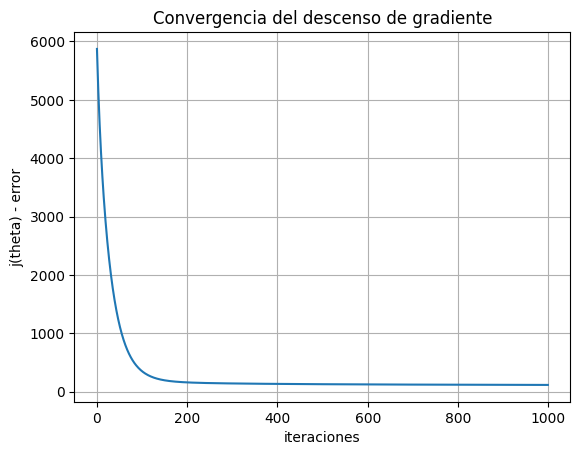

In [91]:
# visializar la convergencia del costo

import matplotlib.pyplot as plt

plt.plot(j_historia)
plt.xlabel("iteraciones")
plt.ylabel("j(theta) - error")
plt.title("Convergencia del descenso de gradiente")
plt.grid(True)
plt.show()

### Funcion de inferencia (prediccion)

Una vez que el descenso de gradiente aprendio `theta_final`, la inferencia es **aplicar la hipotesis a datos nuevos -- "partidos que el modelo nunca vio".

**Detalle importante** los datos nuevos deben normalizarse con los **mismos** `mu` y `sigma` que se utilizo en el entrenamiento. Si no, las escalas no coinciden y la prediccion sera basura.

In [92]:
# Funcion de inferencia

def inferencia(x_nuevo, theta, mu, sigma, n_numericas):
    """
        Predice la duracion (minutos de partido nuevos)

        x_nuevo     : array (k,n) - datos de k partidos nuevos (SIN la columna x0)
        theta       : vector (n+1, ) - parametros aprendidos
        mu, sigma   : vectores (n_numericas, ) - para normalizar igual que en entrenamiento
        n_numericas : int   - cuantas columnas son numericas (para normalizar solo esas)

        Retorna: vector (k, ) con predicciones en minutos
    """
    x_nuevo = x_nuevo.astype(float)

    # Separar numéricas y categóricas
    x_num = x_nuevo[:, :n_numericas]
    x_cat = x_nuevo[:, n_numericas:]

    # Normalizar SOLO las numéricas con los mismos mu/sigma del entrenamiento
    x_num_norm = (x_num - mu) / sigma

    # Combinar: numéricas normalizadas + categóricas sin tocar
    x_norm_nuevo = np.c_[x_num_norm, x_cat]

    # Agregar columna x_0 = 1
    k = x_norm_nuevo.shape[0]
    x_b_nuevo = np.c_[np.ones((k, 1)), x_norm_nuevo]

    # Aplicar hipotesis
    return hipotesis(x_b_nuevo, theta)

In [93]:
# Partido inventado
# 21 numéricas + 16 one-hot = 37 features (+ bias = 38 = len(theta_final))
#
# Numéricas: best_of, winner_rank, loser_rank_points, winner_age, loser_age,
#   w_ace, l_ace, w_df, l_df, w_svpt, l_svpt, w_1stIn, l_1stIn,
#   w_1stWon, l_1stWon, w_2ndWon, l_2ndWon, w_bpSaved, l_bpSaved, w_bpFaced, l_bpFaced
#
# One-hot: surface_Clay, surface_Grass, surface_Hard,
#   tourney_level_D, tourney_level_F, tourney_level_G, tourney_level_M,
#   round_ER, round_F, round_QF, round_R128, round_R16, round_R32, round_R64, round_RR, round_SF

nuevo_partido = np.array([[
    # --- 21 numéricas ---
    5,    # best_of = 5 sets (Grand Slam)
    3,    # winner_rank
    5200, # loser_rank_points
    27,   # winner_age
    29,   # loser_age
    10,   # w_ace
    6,    # l_ace
    2,    # w_df
    4,    # l_df
    85,   # w_svpt
    80,   # l_svpt
    55,   # w_1stIn
    50,   # l_1stIn
    40,   # w_1stWon
    35,   # l_1stWon
    18,   # w_2ndWon
    15,   # l_2ndWon
    8,    # w_bpSaved
    6,    # l_bpSaved
    10,   # w_bpFaced
    9,    # l_bpFaced
    # --- 16 one-hot ---
    1,    # surface_Clay = sí
    0,    # surface_Grass
    0,    # surface_Hard
    0,    # tourney_level_D
    0,    # tourney_level_F
    1,    # tourney_level_G (Grand Slam)
    0,    # tourney_level_M
    0,    # round_ER
    0,    # round_F
    1,    # round_QF (cuartos de final)
    0,    # round_R128
    0,    # round_R16
    0,    # round_R32
    0,    # round_R64
    0,    # round_RR
    0,    # round_SF
]])

prediccion = inferencia(nuevo_partido, theta_final, mu, sigma, len(numericas))
print(f"Duración estimada del partido: {prediccion[0]:.1f} minutos")

Duración estimada del partido: 125.1 minutos


## Tests

In [95]:
# ── Evaluar en el set de PRUEBA ────────────────────────────────────────────
predicciones_test = hipotesis(x_test, theta_final)
errores_test      = predicciones_test - y_test

# MSE (igual que la función de costo * 2)
mse  = np.dot(errores_test, errores_test) / len(y_test)

# RMSE → el error promedio en MINUTOS (más interpretable)
rmse = np.sqrt(mse)

# MAE → error absoluto promedio
mae  = np.mean(np.abs(errores_test))

# R² → qué % de la varianza explica el modelo (1.0 = perfecto, 0 = malo)
ss_res = np.dot(errores_test, errores_test)
ss_tot = np.dot(y_test - y_test.mean(), y_test - y_test.mean())
r2     = 1 - (ss_res / ss_tot)

print(f"── Métricas en TEST SET ({len(y_test)} partidos) ──")
print(f"  RMSE : {rmse:.2f} minutos  ← error promedio del modelo")
print(f"  MAE  : {mae:.2f}  minutos")
print(f"  R²   : {r2:.4f}            ← 1.0 = perfecto")


── Métricas en TEST SET (17536 partidos) ──
  RMSE : 14.29 minutos  ← error promedio del modelo
  MAE  : 10.04  minutos
  R²   : 0.8660            ← 1.0 = perfecto


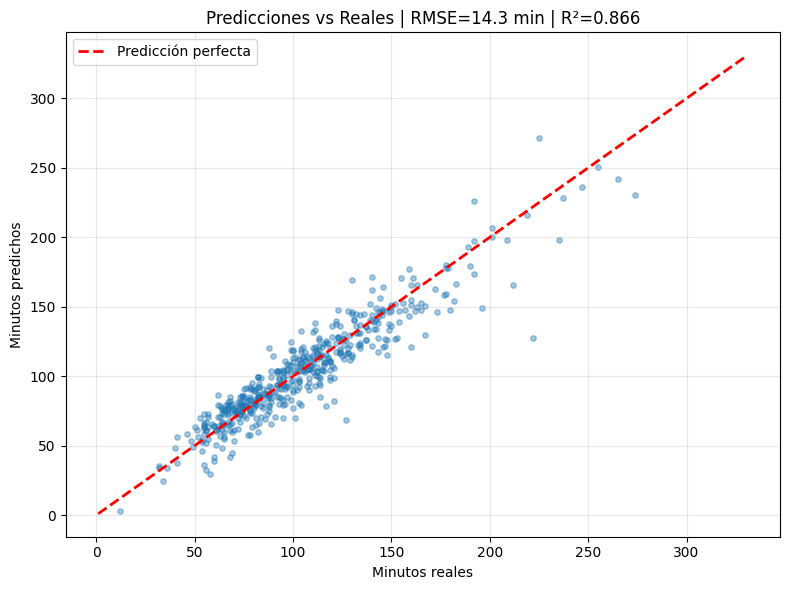

In [96]:
import matplotlib.pyplot as plt

# Muestra solo 500 puntos para que la gráfica no sea tan densa
idx = np.random.choice(len(y_test), 500, replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(y_test[idx], predicciones_test[idx], alpha=0.4, s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label="Predicción perfecta")

plt.xlabel("Minutos reales")
plt.ylabel("Minutos predichos")
plt.title(f"Predicciones vs Reales | RMSE={rmse:.1f} min | R²={r2:.3f}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [97]:
from sklearn.linear_model import LinearRegression

modelo_sk = LinearRegression()
modelo_sk.fit(x_train[:, 1:], y_train)   # sklearn no necesita la columna x₀=1

pred_sk = modelo_sk.predict(x_test[:, 1:])
mse_sk  = np.mean((pred_sk - y_test) ** 2)
rmse_sk = np.sqrt(mse_sk)

print(f"Tu gradient descent → RMSE: {rmse:.2f} min")
print(f"sklearn (solución exacta) → RMSE: {rmse_sk:.2f} min")
# Si los números son similares ✅ tu implementación es correcta


Tu gradient descent → RMSE: 14.29 min
sklearn (solución exacta) → RMSE: 13.14 min
